# 02 — Baseline Models

Establishes a reference pipeline with a Dummy Classifier and Logistic Regression
before the full model comparison in Notebook 03.

In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

In [4]:
import pandas as pd

from src.config import get_project_paths
from src.data import (
    load_processed_dataset, prepare_binary_target,
    split_features_target, create_train_test_split,
    compare_train_test_distribution,
)
from src.preprocessing import create_preprocessor
from src.models import get_baseline_models
from src.evaluation import build_pipeline, run_test_evaluation
from src.plots import save_confusion_matrices, save_metric_bar_plot

In [5]:
paths = get_project_paths()
tables_dir  = paths["tables_dir"]
figures_dir = paths["figures_dir"]

df = load_processed_dataset(paths["processed_data_path"])
df_model = prepare_binary_target(df)
X, y = split_features_target(df_model)

X_train, X_test, y_train, y_test = create_train_test_split(X, y)
print("Train:", X_train.shape, "| Test:", X_test.shape)

compare_train_test_distribution(y_train, y_test)

Train: (456, 10) | Test: (114, 10)


,train_proportion,test_proportion
target,,
0,0.287281,0.289474
1,0.712719,0.710526


## Preprocessing pipeline (fit on X_train only)

In [6]:
# IMPORTANT: create_preprocessor is called with X_train, not full X,
# so feature-name detection is based only on training columns.
preprocessor, numeric_features, categorical_features = create_preprocessor(X_train)
print("Numeric features :", numeric_features)
print("Categorical features:", categorical_features)

Numeric features : ['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin', 'Albumin_and_Globulin_Ratio']
Categorical features: ['Gender']


## Baseline models

In [7]:
baseline_classifiers = get_baseline_models()
baseline_estimators = {
    name: build_pipeline(preprocessor, clf)
    for name, clf in baseline_classifiers.items()
}

In [8]:
baseline_results_df, baseline_trained, baseline_preds = run_test_evaluation(
    baseline_estimators, X_train, X_test, y_train, y_test,
)
baseline_results_df.round(4)

Test evaluation: Dummy Classifier
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.71      1.00      0.83        81

    accuracy                           0.71       114
   macro avg       0.36      0.50      0.42       114
weighted avg       0.50      0.71      0.59       114

Confusion Matrix:
 [[ 0 33]
 [ 0 81]]
Test evaluation: Logistic Regression
              precision    recall  f1-score   support

           0       0.53      0.24      0.33        33
           1       0.75      0.91      0.82        81

    accuracy                           0.72       114
   macro avg       0.64      0.58      0.58       114
weighted avg       0.69      0.72      0.68       114

Confusion Matrix:
 [[ 8 25]
 [ 7 74]]


,Model,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,MCC,TN,FP,FN,TP,ROC-AUC,PR-AUC,Training Time (s),Inference Time (s)
0,Dummy Classifier,0.7105,0.500,0.7105,1.0000,0.0000,0.8308,0.0000,0,33,0,81,0.5000,0.7105,0.0092,0.0036
1,Logistic Regression,0.7193,0.578,0.7475,0.9136,0.2424,0.8222,0.2093,8,25,7,74,0.8032,0.9269,0.0153,0.0054


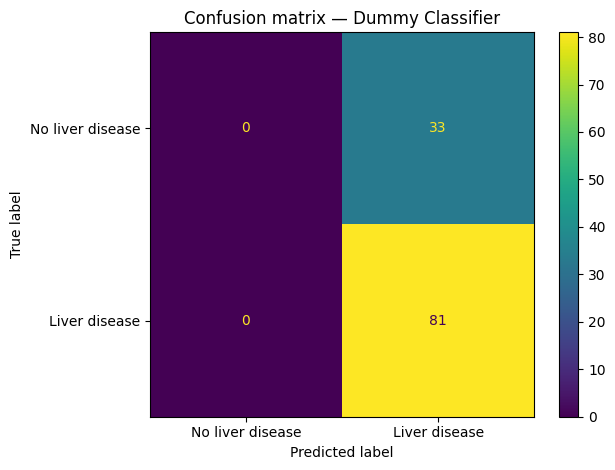

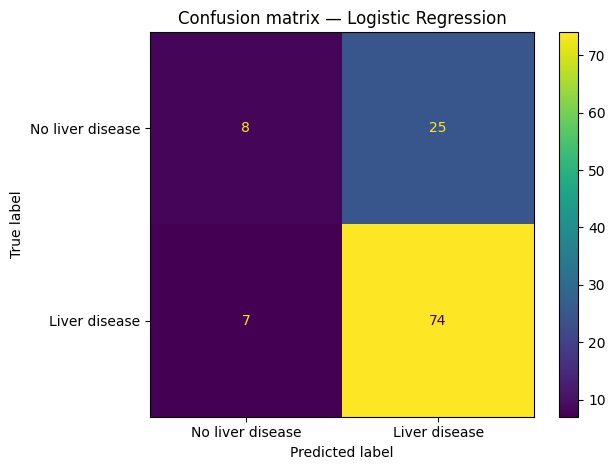

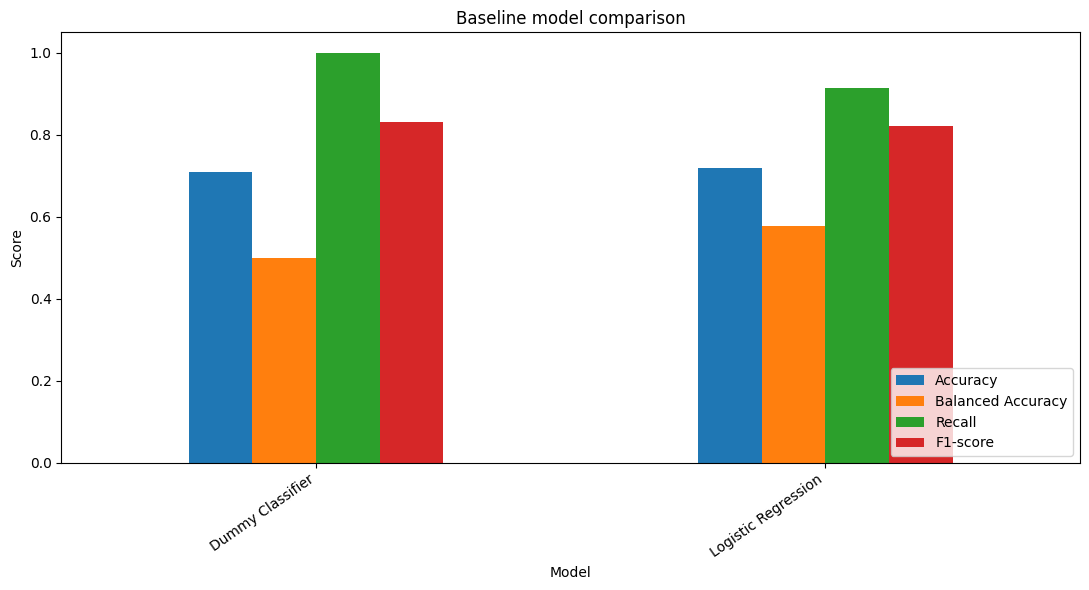

In [9]:
baseline_results_df.to_csv(tables_dir / "baseline_results.csv", index=False)
save_confusion_matrices(baseline_trained, X_test, y_test, figures_dir)
save_metric_bar_plot(
    baseline_results_df,
    metrics=["Accuracy", "Balanced Accuracy", "Recall", "F1-score"],
    figures_dir=figures_dir,
    file_name="baseline_metrics.png",
    title="Baseline model comparison",
)

## Interpretation

The Dummy Classifier (majority-class) achieves ~71 % accuracy by always predicting
liver disease. This illustrates why accuracy alone is misleading on imbalanced data.
Logistic Regression provides the first real learning signal. Full model comparison
follows in Notebook 03.